Epoch [0/2000], Loss: 0.5315
Epoch [200/2000], Loss: 0.0665
Epoch [400/2000], Loss: 0.0126
Epoch [600/2000], Loss: 0.0105
Epoch [800/2000], Loss: 0.0103
Epoch [1000/2000], Loss: 0.0102
Epoch [1200/2000], Loss: 0.0100
Epoch [1400/2000], Loss: 0.0098
Epoch [1600/2000], Loss: 0.0098
Epoch [1800/2000], Loss: 0.0097


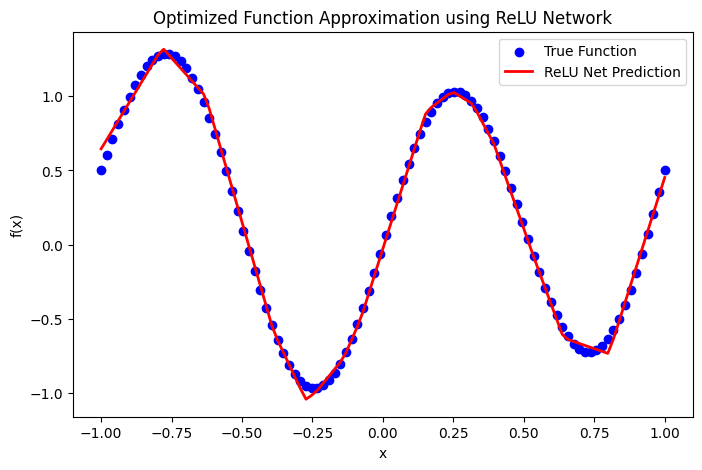

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# 定义目标函数f(x) = sin(2πx) + 0.5x^2
def target_function(x):
    return np.sin(2 * np.pi * x) + 0.5 * x ** 2

# 生成训练数据和测试数据
np.random.seed(0)#设置随机种子以确保可重复性
x_train = np.linspace(-1, 1, 500).reshape(-1, 1)  # 在区间[-1,1]上生成500个训练数据点
noise = np.random.normal(0, 0.1, x_train.shape)  # 添加均值0，标准差0.1的高斯噪声
y_train = target_function(x_train) + noise #生成带噪声的训练标签
x_test = np.linspace(-1, 1, 100).reshape(-1, 1) #在区间[-1，1]上生成100个测试数据点
y_test = target_function(x_test) #生成测试标签（无噪声）

# 转换为 PyTorch 张量
torch.manual_seed(0) #设置PyTorch的随机种子
x_train_tensor = torch.tensor(x_train, dtype=torch.float32)#训练数据
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)#训练标签
x_test_tensor = torch.tensor(x_test, dtype=torch.float32)#测试数据
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)#测试标签

# 定义优化后的两层 ReLU 网络
class ReLUNet(nn.Module):
    def __init__(self):
        super(ReLUNet, self).__init__()
        self.fc1 = nn.Linear(1, 64)  # 第一层全连接层，输入维度1，输出维度64
        self.fc2 = nn.Linear(64, 1)  # 第二次层全连接层，输入维度64，输出维度1
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x)) #第一层：全连接+Relu激活
        x = self.fc2(x) #第二层：全连接（无激活函数）
        return x

# 初始化模型、损失函数和优化器
model = ReLUNet()#实例化模型
criterion = nn.MSELoss()#使用均方误差损失函数
optimizer = optim.Adam(model.parameters(), lr=0.005)  # 使用Adam优化器调整学习率

# 训练模型
num_epochs = 2000  # 训练轮次
for epoch in range(num_epochs):
    optimizer.zero_grad()#清空梯度
    outputs = model(x_train_tensor)#前向传播，计算模型输出
    loss = criterion(outputs, y_train_tensor)#计算损失
    loss.backward()#反向传播，计算梯度
    optimizer.step()#更新模型参数
    
    if epoch % 200 == 0:#每200词打印一次损失
        print(f'Epoch [{epoch}/{num_epochs}], Loss: {loss.item():.4f}')

# 预测测试集
model.eval()#将模型设置为评估模式
with torch.no_grad():#禁用梯度计算
    y_pred = model(x_test_tensor).numpy()#对测试数据进行预测

# 可视化结果
plt.figure(figsize=(8, 5))
plt.scatter(x_test, y_test, label='True Function', color='blue')
plt.plot(x_test, y_pred, label='ReLU Net Prediction', color='red', linewidth=2)
plt.legend()
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Optimized Function Approximation using ReLU Network')
plt.show()
